<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
#!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



In [3]:
# Task 1.1 - Top 5 Databases Respondents Want to Work With

database_df = df[["DatabaseWantToWorkWith"]].copy()

print("Total records:", len(database_df))
print(
    "Valid responses:",
    database_df["DatabaseWantToWorkWith"].notna().sum()
)
print(
    "Missing responses:",
    database_df["DatabaseWantToWorkWith"].isna().sum()
)

# Separate multiple database selections
database_counts = (
    database_df["DatabaseWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

# Select top 5
top5_databases = database_counts.head(5)

display(
    top5_databases
    .rename("Respondents")
    .to_frame()
)

Total records: 65437
Valid responses: 42558
Missing responses: 22879


,Respondents
DatabaseWantToWorkWith,
PostgreSQL,24005
SQLite,13489
MySQL,12269
MongoDB,10982
Redis,10847


The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



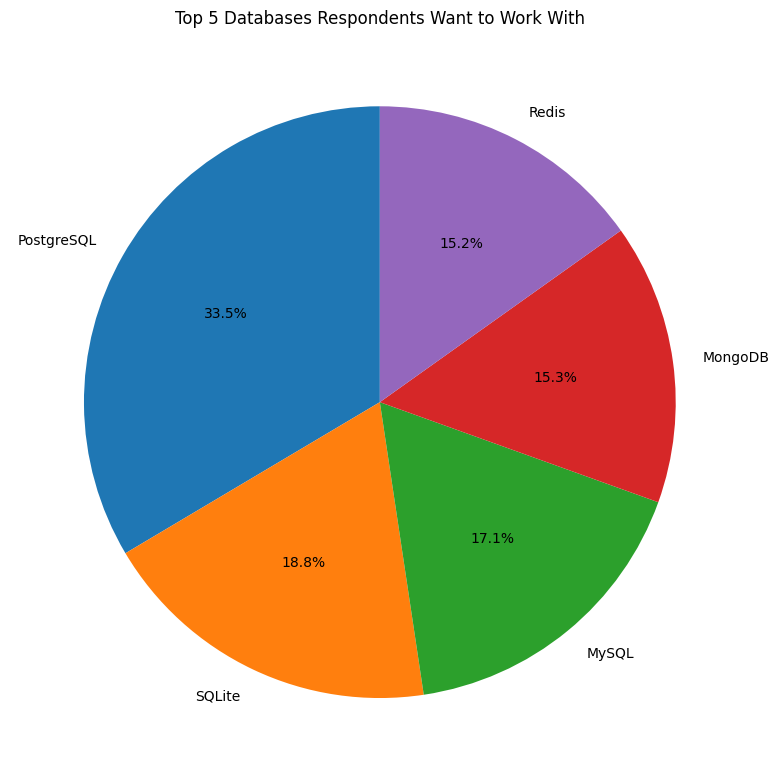

In [ ]:
plt.figure(figsize=(8, 8))

plt.pie(
    top5_databases.values,
    labels=top5_databases.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Top 5 Databases Respondents Want to Work With"
)

plt.tight_layout()
plt.show()

In [7]:
# Task 1.2 - Top 5 Developer Roles

dev_df = df[["DevType"]].copy()

print("Total records:", len(dev_df))
print("Valid responses:", dev_df["DevType"].notna().sum())
print("Missing responses:", dev_df["DevType"].isna().sum())

# Separate multiple developer roles
dev_counts = (
    dev_df["DevType"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

# Top 5 roles
top5_devtypes = dev_counts.head(5)

display(
    top5_devtypes
    .rename("Respondents")
    .to_frame()
)

Total records: 65437
Valid responses: 59445
Missing responses: 5992


,Respondents
DevType,
"Developer, full-stack",18260
"Developer, back-end",9928
Student,5102
"Developer, front-end",3349
"Developer, desktop or enterprise applications",2493


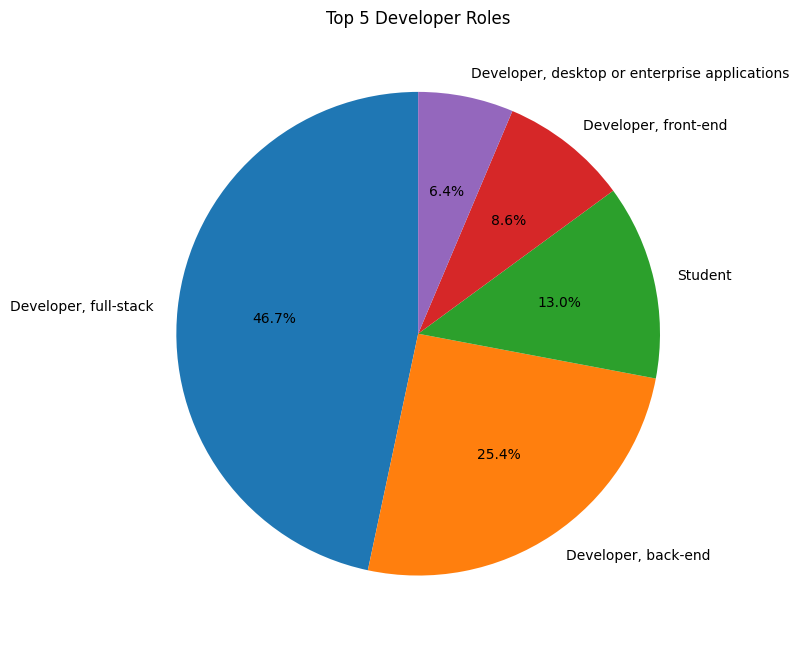

In [8]:
plt.figure(figsize=(8, 8))

plt.pie(
    top5_devtypes.values,
    labels=top5_devtypes.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Developer Roles")

plt.tight_layout()
plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



Total records: 65437
Valid responses: 52973
Missing responses: 12464


,Respondents
OpSysProfessional use,
Windows,27918
MacOS,18625
Ubuntu,16237
Windows Subsystem for Linux (WSL),9859
Debian,5327


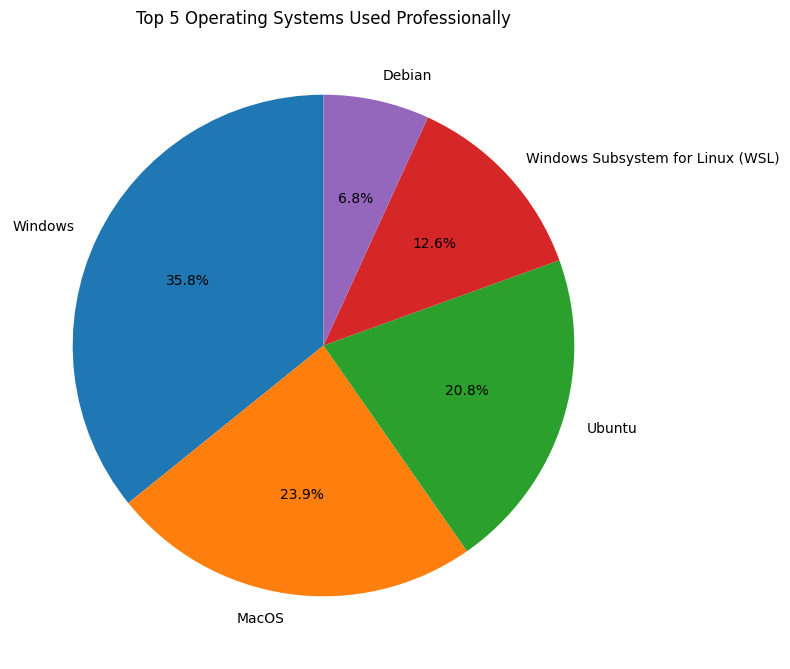

In [10]:
# Task 1.3 - Top Operating Systems Used Professionally

column = "OpSysProfessional use"

# Data quality validation
print("Total records:", len(df))
print("Valid responses:", df[column].notna().sum())
print("Missing responses:", df[column].isna().sum())

# Split multiple operating systems and count them
opsys_counts = (
    df[column]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

# Top 5
top5_opsys = opsys_counts.head(5)

display(
    top5_opsys
    .rename("Respondents")
    .to_frame()
)

# Pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top5_opsys.values,
    labels=top5_opsys.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Operating Systems Used Professionally")
plt.tight_layout()
plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



,Respondents
LanguageHaveWorkedWith,
JavaScript,37492
HTML/CSS,31816
Python,30719
SQL,30682
TypeScript,23150


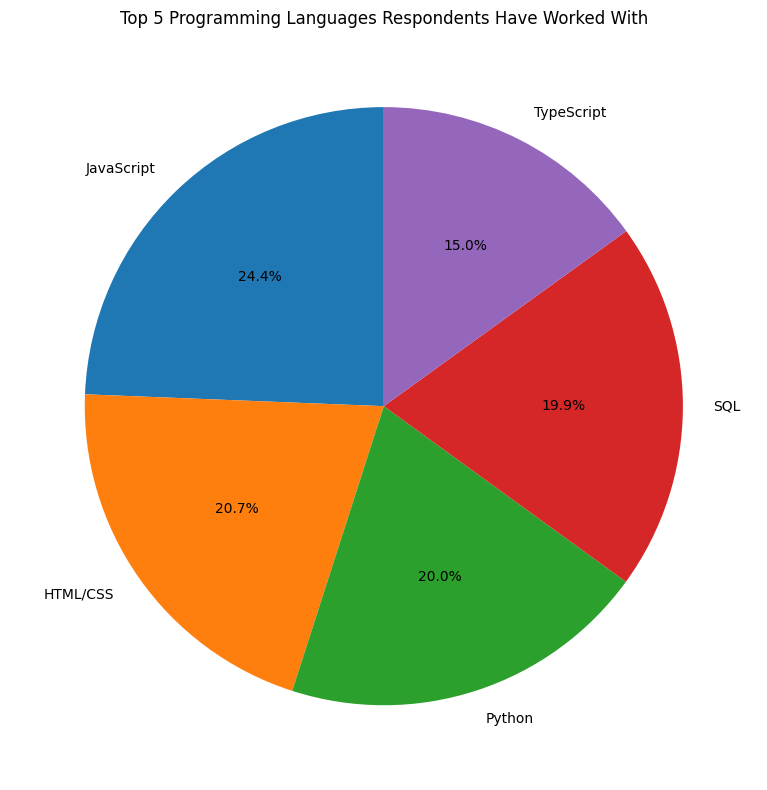

In [11]:
language_counts = (
    df["LanguageHaveWorkedWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

top5_languages = language_counts.head(5)

display(
    top5_languages
    .rename("Respondents")
    .to_frame()
)

plt.figure(figsize=(8, 8))

plt.pie(
    top5_languages.values,
    labels=top5_languages.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Programming Languages Respondents Have Worked With")
plt.tight_layout()
plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



,Respondents
NEWCollabToolsHaveWorkedWith,
Visual Studio Code,42751
Visual Studio,17021
IntelliJ IDEA,15555
Notepad++,13874
Vim,12523


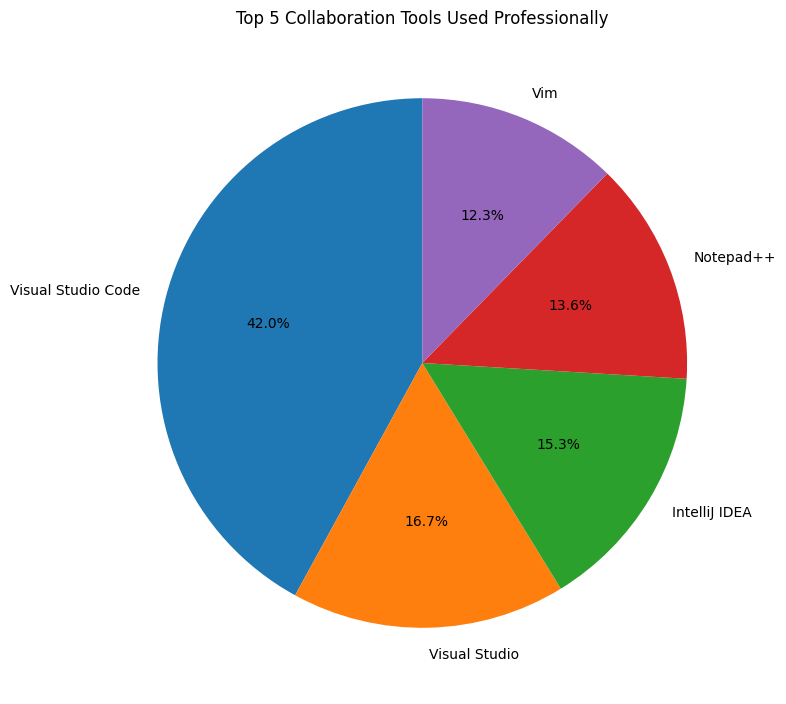

In [12]:
collab_counts = (
    df["NEWCollabToolsHaveWorkedWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

top5_collab = collab_counts.head(5)

display(
    top5_collab
    .rename("Respondents")
    .to_frame()
)

plt.figure(figsize=(8, 8))

plt.pie(
    top5_collab.values,
    labels=top5_collab.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Collaboration Tools Used Professionally")
plt.tight_layout()
plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



,Respondents
LanguageAdmired,
JavaScript,21869
Python,20774
SQL,20692
HTML/CSS,19851
TypeScript,16079


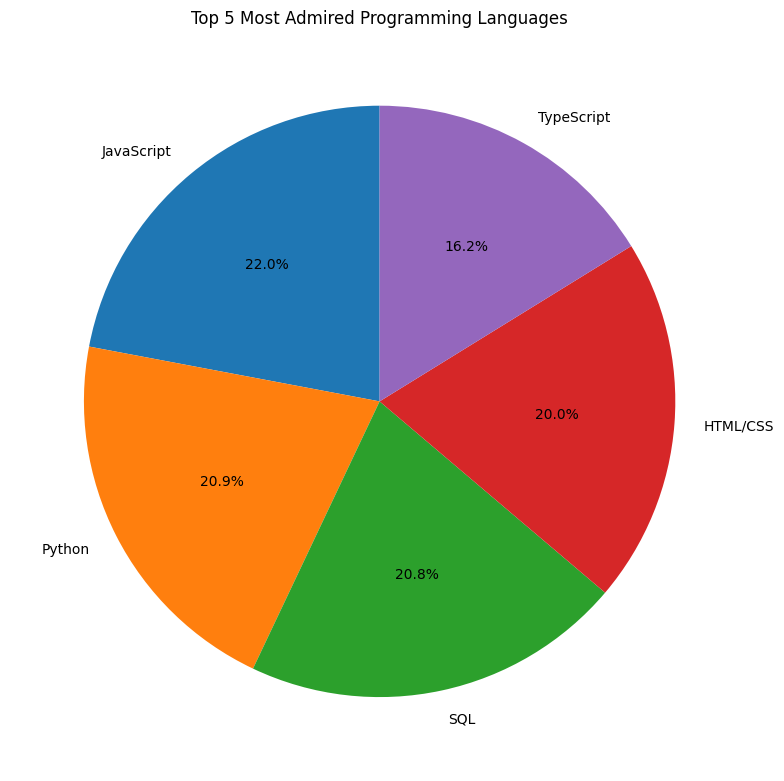

In [13]:
# Task 3.1 - Top 5 Most Admired Programming Languages

admired_counts = (
    df["LanguageAdmired"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

top5_admired = admired_counts.head(5)

display(
    top5_admired
    .rename("Respondents")
    .to_frame()
)

plt.figure(figsize=(8, 8))

plt.pie(
    top5_admired.values,
    labels=top5_admired.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Most Admired Programming Languages")
plt.tight_layout()
plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



,Respondents
AIToolCurrently Using,
Writing code,29486
Search for answers,24295
Debugging and getting help,20404
Documenting code,14439
Generating content or synthetic data,12538


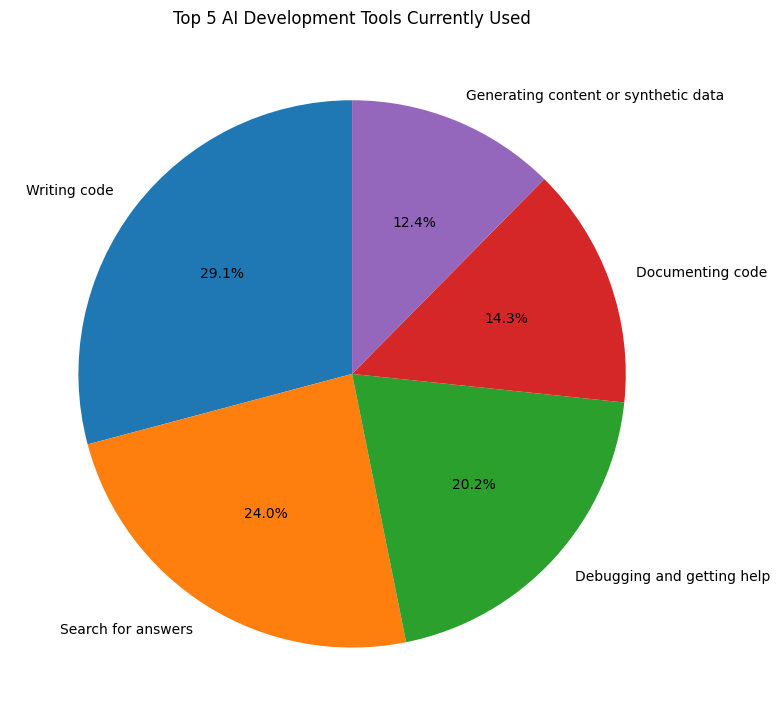

In [14]:
# Task 3.2 - Top AI Development Tools Currently Used

ai_counts = (
    df["AIToolCurrently Using"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

top5_ai = ai_counts.head(5)

display(
    top5_ai
    .rename("Respondents")
    .to_frame()
)

plt.figure(figsize=(8, 8))

plt.pie(
    top5_ai.values,
    labels=top5_ai.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 AI Development Tools Currently Used")
plt.tight_layout()
plt.show()

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



,Respondents
WebframeWantToWorkWith,
React,15404
Node.js,14735
Next.js,8507
Vue.js,7604
ASP.NET CORE,6905


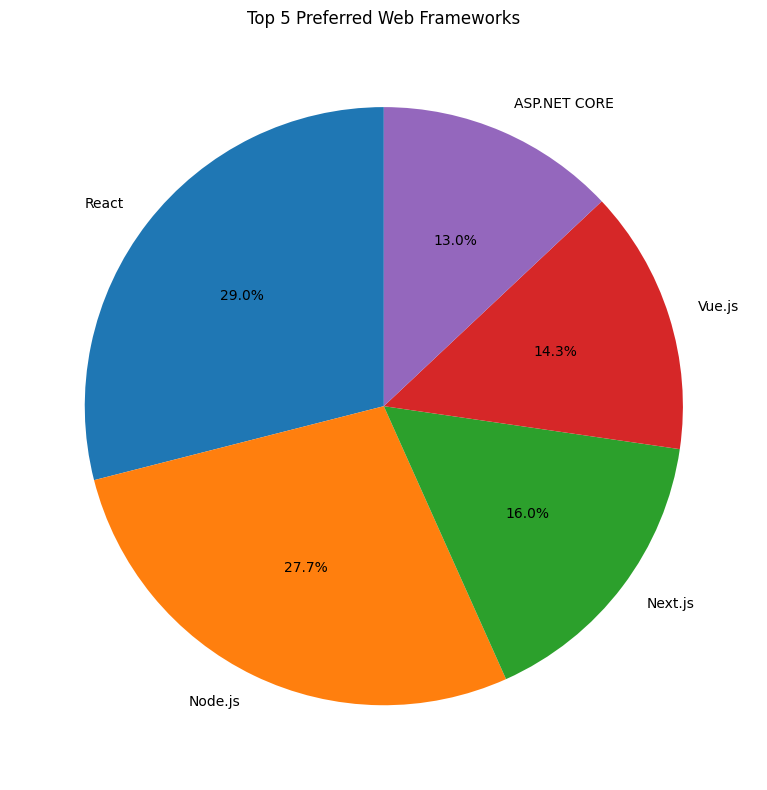

In [15]:
# Task 3.3 - Top 5 Preferred Web Frameworks

framework_counts = (
    df["WebframeWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

top5_frameworks = framework_counts.head(5)

display(
    top5_frameworks
    .rename("Respondents")
    .to_frame()
)

plt.figure(figsize=(8, 8))

plt.pie(
    top5_frameworks.values,
    labels=top5_frameworks.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Preferred Web Frameworks")
plt.tight_layout()
plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



,Respondents
EmbeddedWantToWorkWith,
Rasberry Pi,9792
Arduino,6482
GNU GCC,5870
CMake,4693
Cargo,4567


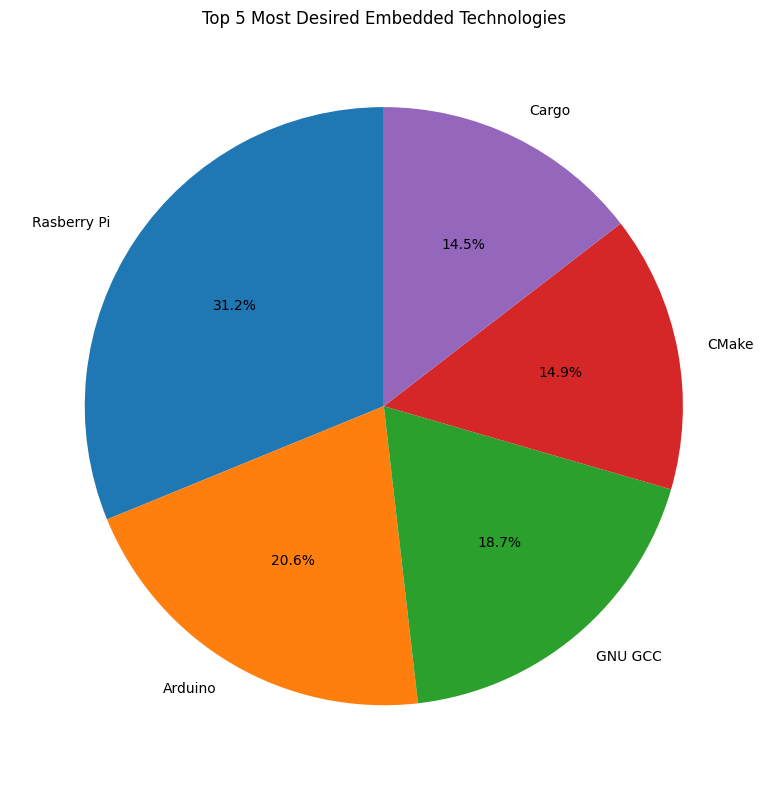

: 

In [ ]:
# Task 3.4 - Top 5 Most Desired Embedded Technologies

embedded_counts = (
    df["EmbeddedWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

top5_embedded = embedded_counts.head(5)

display(
    top5_embedded
    .rename("Respondents")
    .to_frame()
)

plt.figure(figsize=(8, 8))

plt.pie(
    top5_embedded.values,
    labels=top5_embedded.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Most Desired Embedded Technologies")
plt.tight_layout()
plt.show()

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.


